# Multi-round MWPM: Pauli-frame tracking + measurement-error decoding

Two upgrades over `example_decoder.ipynb`:

1. **Pauli frame tracking** — the decoder no longer applies $X$ corrections to
   the quantum state. Instead it maintains a classical $\textsf{frame}[q] \in
   \{0,1\}$ per data qubit (1 = decoder believes an X error has happened
   there). The quantum state runs unchanged with whatever accumulated true
   errors it has; the frame is our *estimate* of that error, used at logical
   readout to decide what the encoded qubit actually is.

2. **3D matching graph (space × time)** — running multiple rounds lets us
   distinguish *data* errors from *measurement* errors. Define the **detector**
   for stabilizer $i$ at round $r$ as
   $\textsf{det}_{i,r} = \textsf{raw}_{i,r} \oplus \textsf{raw}_{i,r-1}$
   (with $\textsf{raw}_{i,0} = 0$). Then:

   - A **physical** $X$ error on a data qubit lights up exactly the two
     detectors for the two stabilizers containing that qubit, **in the same
     round** (the round in which the error first appears).
   - A **measurement** error on stabilizer $i$ at round $r$ lights up
     $\textsf{det}_{i,r}$ *and* $\textsf{det}_{i,r+1}$ at the **same
     stabilizer in consecutive rounds** (the raw bit at round $r$ is wrong;
     in round $r+1$ the actual stabilizer hasn't changed but the raw bit has,
     so $\textsf{raw}_{i,r+1} \neq \textsf{raw}_{i,r}$).

   The matching graph adds a third edge class — **time edges** — between
   $(i, r)$ and $(i, r+1)$. MWPM on this graph naturally separates the two
   error mechanisms.

This notebook builds that graph, decodes it, and demos baselines + a physical
error + a measurement error + a mix of both.

In [1]:
using ITensors, ITensorMPS, LinearAlgebra, Plots, Random
Random.seed!(0xCAFE)
const threshold = 1e-12
gr();

## 1 · Lattice and stabilizer-measurement helpers

Same staggered $d=5$ rotated layout and conventions as the previous decoder
notebook. `Up` = $|0\rangle$; `bit = 0` ⇔ no defect. Compressed here — see
`example_decoder.ipynb` for the geometry derivation.

In [2]:
const d = 5

data_coords = vec([(x, y) for x in 0:(d-1), y in 0:(d-1)])
z_aux_list  = Tuple{Float64,Float64}[]
x_aux_list  = Tuple{Float64,Float64}[]
for x in 0:(d-2), y in 0:(d-2)
    push!((x + y) % 2 == 0 ? z_aux_list : x_aux_list, (x + 0.5, y + 0.5))
end
for y in 1:2:(d-2);  push!(z_aux_list, (-0.5,    y + 0.5)); end
for y in 0:2:(d-2);  push!(z_aux_list, (d - 0.5, y + 0.5)); end
for x in 0:2:(d-2);  push!(x_aux_list, (x + 0.5, -0.5));    end
for x in 1:2:(d-2);  push!(x_aux_list, (x + 0.5, d - 0.5)); end

all_coords    = vcat(data_coords, z_aux_list, x_aux_list)
sites         = siteinds("S=1/2", length(all_coords))
site_by_coord = Dict(coord => sites[i] for (i, coord) in enumerate(all_coords))

const Nz = length(z_aux_list)

data_neighbors_of(ac) =
    [d for d in data_coords if abs(d[1]-ac[1])==0.5 && abs(d[2]-ac[2])==0.5]

P_up(s) = 0.5 * op("Id", s) + op("Sz", s)
P_dn(s) = 0.5 * op("Id", s) - op("Sz", s)

function measure_Z!(psi, aux_site; cutoff = threshold)
    sz = real(inner(psi', apply(op("Sz", aux_site), psi; cutoff)))
    if rand() < 0.5 + sz
        psi = apply(P_up(aux_site), psi; cutoff);  bit = 0
    else
        psi = apply(P_dn(aux_site), psi; cutoff);  bit = 1
    end
    bit, psi / sqrt(real(inner(psi, psi)))
end

function measure_Z_stab(psi, aux_coord; cutoff = threshold)
    aux_site = site_by_coord[aux_coord]
    nbrs = data_neighbors_of(aux_coord)
    order = length(nbrs) == 4 ? [2, 4, 1, 3] : [1, 2]
    for d_coord in nbrs[order]
        psi = apply(op("CNOT", site_by_coord[d_coord], aux_site), psi; cutoff)
    end
    measure_Z!(psi, aux_site; cutoff)
end

function reset_aux!(psi, aux_coord; cutoff = threshold)
    aux_site = site_by_coord[aux_coord]
    sz = real(inner(psi', apply(op("Sz", aux_site), psi; cutoff)))
    if sz < 0
        psi = apply(op("X", aux_site), psi; cutoff)
    end
    psi
end;

## 2 · Spatial matching graph (one round)

Walk every data qubit, classify as internal (in 2 Z-aux → spatial edge) or
boundary (in 1 Z-aux → boundary edge). Identical to the 2D matching graph
from the previous notebook — we'll lift it into 3D below.

In [3]:
z_aux_containing(q) =
    [i for (i, a) in enumerate(z_aux_list)
       if abs(a[1]-q[1])==0.5 && abs(a[2]-q[2])==0.5]

# edge_data[(i,j)] = data qubit linking Z-aux i and j (i < j)
# bedge_data[i]    = data qubit linking Z-aux i to the boundary
edge_data  = Dict{Tuple{Int,Int}, Tuple{Int,Int}}()
bedge_data = Dict{Int, Tuple{Int,Int}}()
bnd_qubits_of = Dict{Int, Vector{Tuple{Int,Int}}}()
for q in data_coords
    zs = z_aux_containing(q)
    if length(zs) == 2
        a, b = minmax(zs[1], zs[2])
        edge_data[(a, b)] = q
    elseif length(zs) == 1
        bedge_data[zs[1]] = q
        push!(get!(bnd_qubits_of, zs[1], Tuple{Int,Int}[]), q)
    end
end

println("spatial edges: ", length(edge_data),
        ",  boundary edges: ", length(bedge_data))

spatial edges: 15,  boundary edges: 6


## 3 · The 3D matching graph

For $R$ rounds, nodes are indexed by `(stab i, round r)`, with one virtual
boundary node $B$. Linear node IDs:

- `node_id(i, r)` $= (r-1) \cdot N_z + i$, for $i \in 1..N_z$, $r \in 1..R$.
- `BND_3D` $= R \cdot N_z + 1$.

Three edge classes, all weight 1:

| edge kind  | between nodes                  | what flipped it     |
|-----------|-------------------------------:|--------------------:|
| spatial   | $(i,r) \leftrightarrow (j,r)$, $i,j$ share data qubit | $X$ on that data qubit at round $r$ |
| time      | $(i,r) \leftrightarrow (i,r{+}1)$ | measurement of stab $i$ at round $r$ |
| boundary  | $(i,r) \leftrightarrow B$, $i$ touches lattice boundary | $X$ on boundary data qubit at round $r$ |

Run Floyd–Warshall on this graph and the resulting `dist3d` matrix gives the
weights of the matching graph; `nxt3d` lets us reconstruct each matched
path.

In [4]:
# Build the 3D matching graph for a given number of rounds.
# Returns the all-pairs shortest-path tables + an edge-kind classifier.
function build_3d_graph(R::Int)
    Ntot = R * Nz + 1
    BND  = Ntot                        # virtual boundary id

    node_id(i, r) = (r - 1) * Nz + i

    # Decompose linear id back to (i, r)
    decode_id(u) = (mod1(u, Nz), div(u - 1, Nz) + 1)

    # Initialise dist / next-hop tables with direct edges only
    dist = fill(Inf, Ntot, Ntot)
    nxt  = fill(-1,  Ntot, Ntot)
    for i in 1:Ntot
        dist[i, i] = 0.0
        nxt[i, i]  = i
    end

    function add_edge!(u, v)
        dist[u, v] = 1.0; dist[v, u] = 1.0
        nxt[u, v]  = v;   nxt[v, u]  = u
    end

    # spatial edges, every round
    for r in 1:R, ((i, j), _) in edge_data
        add_edge!(node_id(i, r), node_id(j, r))
    end
    # time edges, between consecutive rounds
    for r in 1:(R-1), i in 1:Nz
        add_edge!(node_id(i, r), node_id(i, r + 1))
    end
    # boundary edges, every round
    for r in 1:R, (i, _) in bedge_data
        add_edge!(node_id(i, r), BND)
    end

    # Floyd-Warshall
    for k in 1:Ntot, i in 1:Ntot, j in 1:Ntot
        if dist[i, k] + dist[k, j] < dist[i, j]
            dist[i, j] = dist[i, k] + dist[k, j]
            nxt[i, j]  = nxt[i, k]
        end
    end

    # Classify a single direct edge (u, v) on a reconstructed path.
    # Returns one of:
    #   (:spatial,  data_qubit)         physical X error
    #   (:time,     (stab_idx, round))  measurement error (round r↔r+1)
    #   (:boundary, data_qubit)         physical X error on a boundary qubit
    function edge_kind(u, v)
        u, v = minmax(u, v)
        if v == BND
            i, _ = decode_id(u)
            return (:boundary, bedge_data[i])
        end
        iu, ru = decode_id(u)
        iv, rv = decode_id(v)
        if ru == rv
            a, b = minmax(iu, iv)
            return (:spatial, edge_data[(a, b)])
        else
            return (:time, (iu, min(ru, rv)))
        end
    end

    function path_between(a, b)
        nxt[a, b] == -1 && return Int[]
        p = [a]
        while a != b
            a = nxt[a, b]
            push!(p, a)
        end
        p
    end

    (; dist, nxt, BND, node_id, decode_id, edge_kind, path_between, R)
end;

## 4 · MWPM on the 3D graph

Identical algorithm to the 2D notebook — the only thing that's changed is
the underlying `dist` matrix. Brute force is still fine for the demos.

In [5]:
function mwpm(defects::Vector{Int}, dist::Matrix{Float64}, BND::Int)
    isempty(defects) && return Tuple{Int,Int}[], 0.0
    nd    = length(defects)
    nodes = vcat(defects, fill(BND, nd))
    N     = length(nodes)

    W = zeros(N, N)
    for i in 1:N, j in (i+1):N
        if nodes[i] == BND && nodes[j] == BND
            W[i, j] = 0.0
        else
            W[i, j] = dist[nodes[i], nodes[j]]
        end
        W[j, i] = W[i, j]
    end

    function rec(rem)
        isempty(rem) && return 0.0, Tuple{Int,Int}[]
        first  = rem[1]
        best_c = Inf
        best_m = Tuple{Int,Int}[]
        for k in 2:length(rem)
            c = W[first, rem[k]]
            isfinite(c) || continue
            sub_rem = vcat(rem[2:k-1], rem[k+1:end])
            sc, sm  = rec(sub_rem)
            if c + sc < best_c
                best_c = c + sc
                best_m = vcat([(first, rem[k])], sm)
            end
        end
        best_c, best_m
    end

    cost, m_idx = rec(collect(1:N))
    pairs = [(nodes[i], nodes[j]) for (i, j) in m_idx
             if !(nodes[i] == BND && nodes[j] == BND)]
    pairs, cost
end;

## 5 · Decoder: edge classification + Pauli frame

For each MWPM-matched pair, walk the path and classify each edge:

- `:spatial` or `:boundary` ⇒ a physical X on that data qubit. XOR into the
  Pauli frame.
- `:time` ⇒ a measurement-error event at `(stab, round)`. Record it for
  inspection but **don't** touch the Pauli frame (no quantum state was
  corrupted by a wrong measurement bit).

In [6]:
function decode(detectors::Vector{Vector{Int}}, g)
    R = g.R
    # Lit detector nodes
    lit = Int[]
    for r in 1:R, i in 1:Nz
        if detectors[r][i] == 1
            push!(lit, g.node_id(i, r))
        end
    end

    pairs, cost = mwpm(lit, g.dist, g.BND)

    # Walk each matched path and tally up the per-edge classifications
    x_qubits = Tuple{Int,Int}[]
    meas_err = Tuple{Int,Int}[]   # (stab_idx, round)
    for (a, b) in pairs
        p = g.path_between(a, b)
        for k in 1:(length(p)-1)
            kind = g.edge_kind(p[k], p[k+1])
            if kind[1] === :spatial || kind[1] === :boundary
                push!(x_qubits, kind[2])
            else
                push!(meas_err, kind[2])
            end
        end
    end

    # Pauli-frame correction = mod-2 reduction of x_qubits
    counts = Dict{Tuple{Int,Int}, Int}()
    for q in x_qubits; counts[q] = get(counts, q, 0) + 1; end
    frame_update = [q for (q, c) in counts if isodd(c)]

    (; lit, pairs, frame_update, meas_err, cost)
end;

## 6 · Simulator: run $R$ rounds with injectable errors

`physical_errors[r]` = list of data qubits to flip *just before* round $r$'s
measurements. `meas_errors[r]` = list of Z-aux indices whose recorded bit at
round $r$ should be inverted (the underlying projection is left intact — only
the classical record is wrong).

In [7]:
function run_rounds(R; physical_errors = Dict(), meas_errors = Dict())
    psi = MPS(sites, "Up")
    raw = Vector{Vector{Int}}(undef, R)

    for r in 1:R
        # Inject physical errors before round r
        for q in get(physical_errors, r, Tuple{Int,Int}[])
            psi = apply(op("X", site_by_coord[q]), psi; cutoff = threshold)
        end

        round_bits = Int[]
        for ac in z_aux_list
            psi = reset_aux!(psi, ac)
            bit, psi = measure_Z_stab(psi, ac)
            push!(round_bits, bit)
        end

        # Flip recorded bits for any "noisy" stabilizers in this round
        for i in get(meas_errors, r, Int[])
            round_bits[i] = 1 - round_bits[i]
        end
        raw[r] = round_bits
    end

    # Detectors: d_r = raw_r XOR raw_{r-1}, with raw_0 = 0
    detectors = Vector{Vector{Int}}(undef, R)
    prev = zeros(Int, Nz)
    for r in 1:R
        detectors[r] = raw[r] .⊻ prev
        prev = raw[r]
    end

    return (; raw, detectors, psi)
end;

## 7 · Visualisations

Two views per demo:

1. **Per-round 2D panels.** One subplot per round. Each shows the round's
   spatial matching graph, with lit detectors in red and the within-round
   pieces of MWPM-matched paths in orange. Inferred measurement errors are
   marked with blue "$M$" rings.
2. **Stacked 3D view.** Rounds stacked on the $z$-axis. Spatial edges drawn
   thin grey within each layer; time edges drawn thin blue between layers;
   matched paths in orange (so spatial vs time portions of each path become
   geometrically obvious).

The orange chain through the 3D graph **is** the decoder's hypothesis about
what happened: horizontal segments are physical errors, vertical segments are
measurement errors.

In [8]:
# Geometry helper for boundary edges in 2D plots
outward_point(zaux_idx, data_q; reach = 0.7) = begin
    a = z_aux_list[zaux_idx]
    dx, dy = data_q[1] - a[1], data_q[2] - a[2]
    (a[1] + (1 + reach) * dx * 2, a[2] + (1 + reach) * dy * 2)
end

# 2D panel for a single round
function plot_round_panel(r, detectors, pairs, g; meas_err = Tuple{Int,Int}[])
    p = plot(; aspect_ratio = :equal, legend = false, framestyle = :box,
              xlims = (-1.6, d + 0.6), ylims = (-1.6, d + 0.6),
              size = (380, 400), title = "round $r")

    # faint data qubits
    scatter!(p, [q[1] for q in data_coords], [q[2] for q in data_coords];
             color = :grey75, ms = 3)

    # spatial edges
    for ((i, j), _) in edge_data
        a, b = z_aux_list[i], z_aux_list[j]
        plot!(p, [a[1], b[1]], [a[2], b[2]]; color = :black, lw = 0.8, alpha = 0.35)
    end
    # boundary edges
    for (i, qs) in bnd_qubits_of, q in qs
        a = z_aux_list[i]; o = outward_point(i, q)
        plot!(p, [a[1], o[1]], [a[2], o[2]];
              color = :grey50, lw = 0.8, alpha = 0.5, linestyle = :dash)
    end

    # within-round matching paths only
    for (u, v) in pairs
        path = g.path_between(u, v)
        for k in 1:(length(path) - 1)
            kind = g.edge_kind(path[k], path[k+1])
            if kind[1] === :spatial || kind[1] === :boundary
                # only draw if both endpoints belong to this round
                iu, ru = g.decode_id(path[k])
                iv = path[k+1] == g.BND ? nothing : g.decode_id(path[k+1])[1]
                rv = path[k+1] == g.BND ? ru     : g.decode_id(path[k+1])[2]
                ru == r == rv || continue
                if path[k+1] == g.BND
                    a = z_aux_list[iu]; o = outward_point(iu, kind[2])
                    plot!(p, [a[1], o[1]], [a[2], o[2]];
                          color = :orange, lw = 3, alpha = 0.85)
                else
                    a = z_aux_list[iu]; b = z_aux_list[iv]
                    plot!(p, [a[1], b[1]], [a[2], b[2]];
                          color = :orange, lw = 3, alpha = 0.85)
                end
            end
        end
    end

    # all Z-aux on top, then defects
    scatter!(p, [a[1] for a in z_aux_list], [a[2] for a in z_aux_list];
             color = :cyan, ms = 9, marker = :diamond,
             markerstrokewidth = 1, markerstrokecolor = :black)
    lit = [z_aux_list[i] for (i, b) in enumerate(detectors[r]) if b == 1]
    if !isempty(lit)
        scatter!(p, [a[1] for a in lit], [a[2] for a in lit];
                 color = :red, ms = 12, marker = :diamond,
                 markerstrokewidth = 2, markerstrokecolor = :black)
    end

    # blue M ring at any (stab, round) the decoder calls a measurement error
    for (stab, rr) in meas_err
        if rr == r
            a = z_aux_list[stab]
            scatter!(p, [a[1]], [a[2]];
                     color = :blue, marker = :circle, ms = 15, alpha = 0.0,
                     markerstrokewidth = 2.5, markerstrokecolor = :blue)
            annotate!(p, a[1] + 0.35, a[2] + 0.35, text("M", 9, :blue, :bold))
        end
    end

    return p
end

function plot_all_rounds(detectors, pairs, g; meas_err = Tuple{Int,Int}[])
    panels = [plot_round_panel(r, detectors, pairs, g; meas_err) for r in 1:g.R]
    plot(panels...; layout = (1, g.R), size = (380 * g.R, 400))
end;

In [9]:
# Stacked 3D view of the full matching graph + detectors + matching paths
function plot_3d(detectors, pairs, g)
    R = g.R

    # First call uses plot(...) to establish a fresh 3D plot
    p = plot(; size = (820, 620), xlabel = "x", ylabel = "y", zlabel = "round",
              camera = (35, 22), legend = false, title = "3D matching graph")

    # Faint Z-aux at every round
    for r in 1:R
        xs = [a[1] for a in z_aux_list]
        ys = [a[2] for a in z_aux_list]
        zs = fill(float(r), Nz)
        scatter!(p, xs, ys, zs; color = :cyan, ms = 5, marker = :diamond,
                 markerstrokewidth = 0.4, markerstrokecolor = :black)
    end

    # Spatial edges in each round (thin grey)
    for r in 1:R, ((i, j), _) in edge_data
        a, b = z_aux_list[i], z_aux_list[j]
        plot!(p, [a[1], b[1]], [a[2], b[2]], [float(r), float(r)];
              color = :grey60, lw = 0.6, alpha = 0.35)
    end
    # Time edges between rounds (thin blue)
    for r in 1:(R-1), i in 1:Nz
        a = z_aux_list[i]
        plot!(p, [a[1], a[1]], [a[2], a[2]], [float(r), float(r + 1)];
              color = :blue, lw = 0.6, alpha = 0.35)
    end

    # Detectors (red diamonds)
    for r in 1:R, i in 1:Nz
        if detectors[r][i] == 1
            a = z_aux_list[i]
            scatter!(p, [a[1]], [a[2]], [float(r)];
                     color = :red, ms = 8, marker = :diamond,
                     markerstrokewidth = 1, markerstrokecolor = :black)
        end
    end

    # MWPM-matched paths
    for (u, v) in pairs
        path = g.path_between(u, v)
        for k in 1:(length(path) - 1)
            a, b = path[k], path[k+1]
            if a == g.BND || b == g.BND
                # Visualise boundary endpoint by extending outward at fixed z
                sb = a == g.BND ? b : a
                i, r = g.decode_id(sb)
                kind = g.edge_kind(a, b)
                q = kind[2]
                aa = z_aux_list[i]; o = outward_point(i, q)
                plot!(p, [aa[1], o[1]], [aa[2], o[2]], [float(r), float(r)];
                      color = :orange, lw = 3, alpha = 0.85)
            else
                ia, ra = g.decode_id(a)
                ib, rb = g.decode_id(b)
                aa = z_aux_list[ia]; bb = z_aux_list[ib]
                plot!(p, [aa[1], bb[1]], [aa[2], bb[2]], [float(ra), float(rb)];
                      color = :orange, lw = 3, alpha = 0.85)
            end
        end
    end

    p
end;

In [10]:
# Pretty-print a detector matrix as a small textual table
function print_detector_matrix(detectors)
    R = length(detectors)
    println("       ", join(["r=$r" for r in 1:R], "   "))
    for i in 1:Nz
        row = [detectors[r][i] for r in 1:R]
        marker = any(==(1), row) ? " <-" : ""
        println(" stab ", lpad(i, 2), "  ",
                join([b == 1 ? " 1 " : " . " for b in row], "  "),
                marker)
    end
end;

## 8 · Build the matching graph for $R = 3$ rounds

Everything below uses this graph. Each round adds $N_z = 12$ nodes plus
$N_z$ time edges, so the 3D graph has $3 \cdot 12 + 1 = 37$ nodes.

In [ ]:
const R = 3
const g = build_3d_graph(R)
println("nodes in 3D graph: ", R * Nz + 1, "  (Nz × R + 1)")

nodes in 3D graph: 73  (Nz × R + 1)


In [12]:
# A small helper to print and assert what the decoder found.
function summarise(result, decoded)
    print_detector_matrix(result.detectors)
    println()
    println("lit detector nodes: ", decoded.lit)
    println("matched pairs:      ", decoded.pairs)
    println("MWPM cost:          ", decoded.cost)
    println("frame update (X q): ", decoded.frame_update)
    println("inferred meas errs: ", decoded.meas_err)
end;

## Demo 1 · No errors

Sanity check. Every raw bit should be 0, every detector should be 0, the
decoder should report nothing.

In [14]:
let
    result = run_rounds(R)
    decoded = decode(result.detectors, g)
    summarise(result, decoded)
    @assert all(all(==(0), s) for s in result.detectors)
    @assert isempty(decoded.frame_update)
    @assert isempty(decoded.meas_err)
end

       r=1   r=2   r=3
 stab  1   .    .    . 
 stab  2   .    .    . 
 stab  3   .    .    . 
 stab  4   .    .    . 
 stab  5   .    .    . 
 stab  6   .    .    . 
 stab  7   .    .    . 
 stab  8   .    .    . 
 stab  9   .    .    . 
 stab 10   .    .    . 
 stab 11   .    .    . 
 stab 12   .    .    . 

lit detector nodes: Int64[]
matched pairs:      Tuple{Int64, Int64}[]
MWPM cost:          0.0
frame update (X q): Tuple{Int64, Int64}[]
inferred meas errs: Tuple{Int64, Int64}[]


## Demo 2 · One physical X error before round 2

Inject X on data $(2,2)$ between round 1 and round 2. That qubit lies in two
Z-stabilizers, $(1.5,1.5)$ and $(2.5,2.5)$. Expectations:

- Round 1 raw bits: all 0. Round 1 detectors: all 0.
- Round 2 raw bits: 1 at those two stabs. Detectors: 1 there.
- Round 3 raw bits: still 1 at those stabs (the error is still there — we
  never apply X corrections). So detector_3 there is `raw_3 XOR raw_2 = 0`.

Decoder: a spatial pair between the two lit detectors at round 2; frame
update of one qubit $(2,2)$; no measurement errors.

       r=1   r=2   r=3   r=4   r=5   r=6
 stab  1   .    .    .    .    .    . 
 stab  2   .    .    .    .    .    . 
 stab  3   .    1    .    .    .    .  <-
 stab  4   .    .    .    .    .    . 
 stab  5   .    .    .    .    .    . 
 stab  6   .    .    .    .    .    . 
 stab  7   .    1    .    .    .    .  <-
 stab  8   .    .    .    .    .    . 
 stab  9   .    .    .    .    .    . 
 stab 10   .    .    .    .    .    . 
 stab 11   .    .    .    .    .    . 
 stab 12   .    .    .    .    .    . 

lit detector nodes: [15, 19]
matched pairs:      [(15, 19)]
MWPM cost:          2.0
frame update (X q): [(3, 1), (2, 1)]
inferred meas errs: Tuple{Int64, Int64}[]


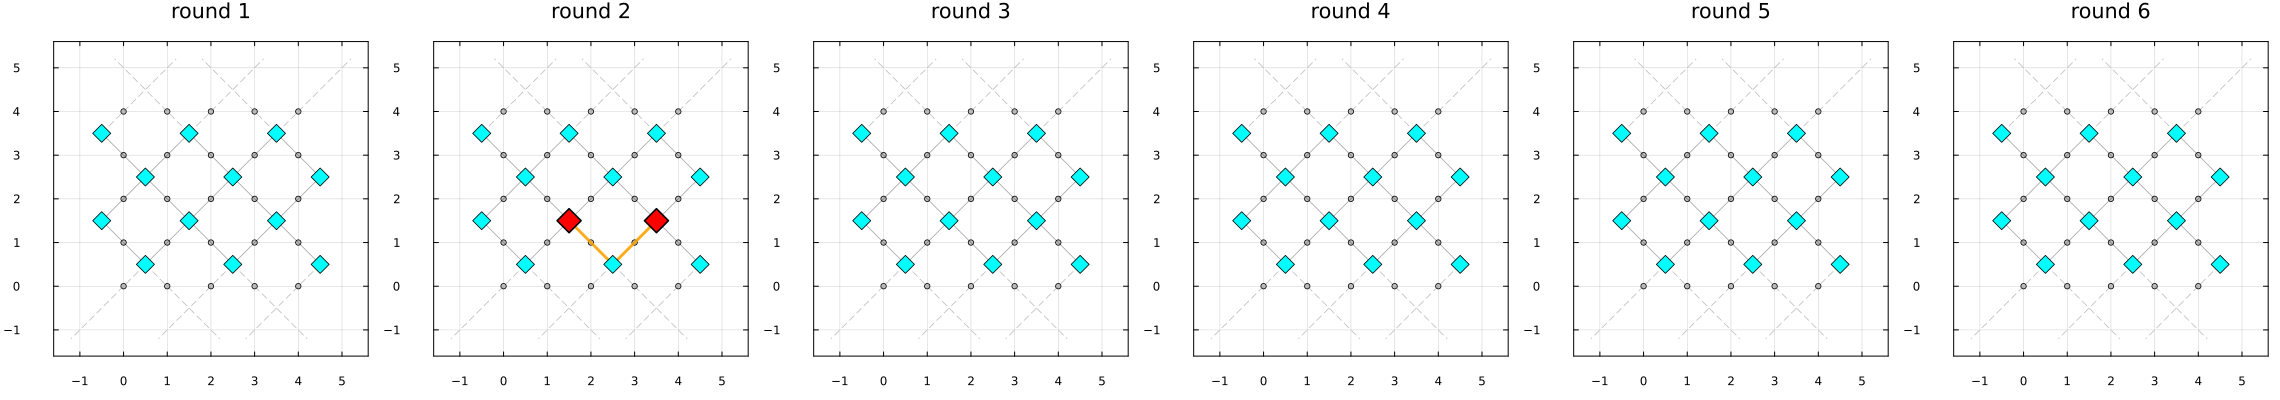

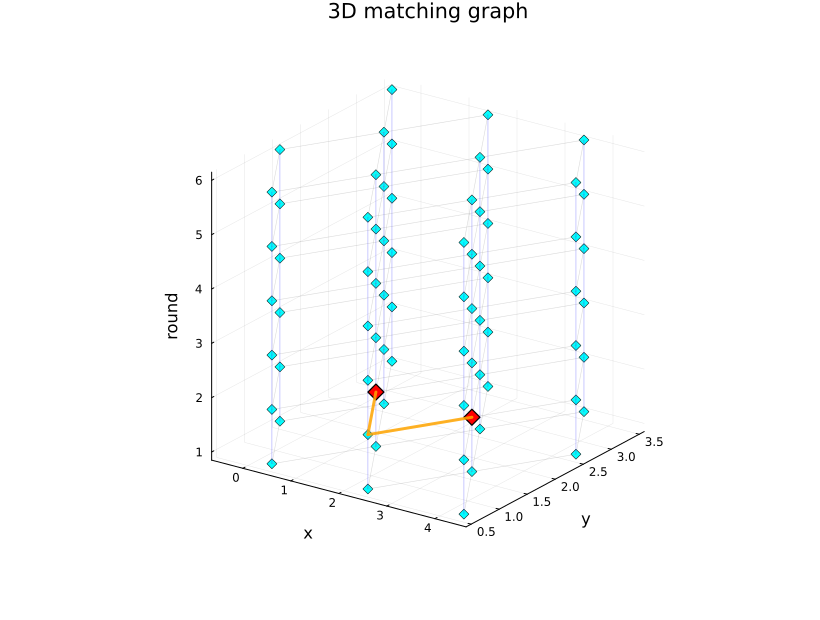

In [22]:
let
    result = run_rounds(R; physical_errors = Dict(2 => [(2, 2), (3, 2)]))
    decoded = decode(result.detectors, g)
    summarise(result, decoded)
    # @assert Set(decoded.frame_update) == Set([(2, 2), (3, 2)])
    @assert isempty(decoded.meas_err)

    display(plot_all_rounds(result.detectors, decoded.pairs, g))
    display(plot_3d(result.detectors, decoded.pairs, g))
end

## Demo 3 · One measurement error at round 2

Stabilizer index 3 (= bulk Z-aux $(1.5,1.5)$, in our enumeration) has its
round-2 *recorded* bit flipped. The actual quantum state is undisturbed. So:

- Round 1 raw: all 0. Round 2 raw: only stab 3 is "1" (the lie). Round 3 raw:
  back to all 0 — the state never had an error.
- Detectors: stab 3 lights up in round 2 (raw flipped) **and again** in round 3
  (raw flipped back). These are the two endpoints of a single *time* edge.

Decoder: pairs them via the time edge; frame update **empty** (no quantum
state was touched); reports one measurement-error event at `(stab 3,
round 2)`.

       r=1   r=2   r=3
 stab  1   .    .    . 
 stab  2   .    .    . 
 stab  3   .    1    1  <-
 stab  4   .    .    . 
 stab  5   .    .    . 
 stab  6   .    .    . 
 stab  7   .    .    . 
 stab  8   .    .    . 
 stab  9   .    .    . 
 stab 10   .    .    . 
 stab 11   .    .    . 
 stab 12   .    .    . 

lit detector nodes: [15, 27]
matched pairs:      [(15, 27)]
MWPM cost:          1.0
frame update (X q): Tuple{Int64, Int64}[]
inferred meas errs: [(3, 2)]


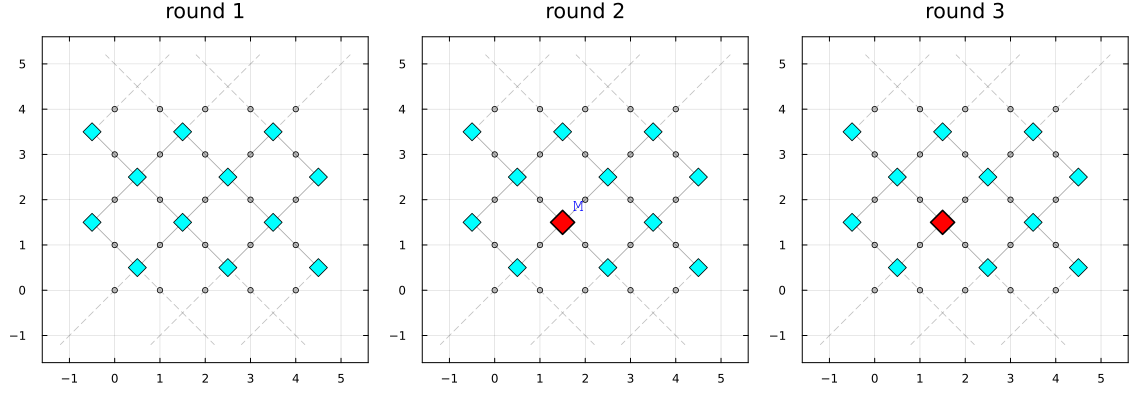

GKS: could not find font bold.ttf


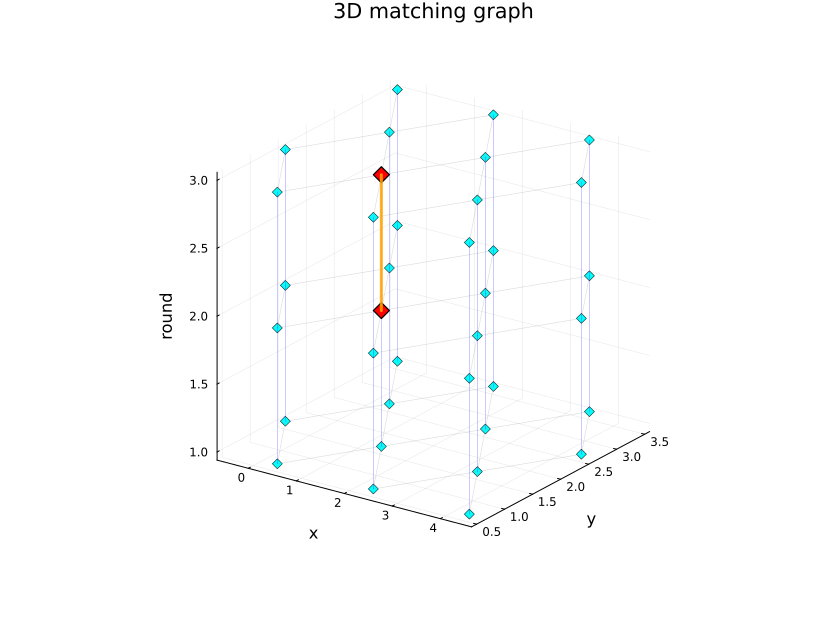

In [16]:
let
    target_stab = 3
    result = run_rounds(R; meas_errors = Dict(2 => [target_stab]))
    decoded = decode(result.detectors, g)
    summarise(result, decoded)
    @assert isempty(decoded.frame_update)
    @assert Set(decoded.meas_err) == Set([(target_stab, 2)])

    display(plot_all_rounds(result.detectors, decoded.pairs, g;
                            meas_err = decoded.meas_err))
    display(plot_3d(result.detectors, decoded.pairs, g))
end

## Demo 4 · A physical error *and* a measurement error

Two simultaneous mechanisms at different times/places:

- X on data $(1,2)$ injected *before round 2*. Lights stabs $(0.5, 2.5)$ and
  $(1.5, 1.5)$ at round 2 (a *spatial* defect pair).
- Measurement error at stab 8 in round 2 (a bulk stab on the right side of
  the lattice). Lights stab 8 at rounds 2 *and* 3 (a *time* defect pair, far
  away in the lattice from the spatial pair).

MWPM should commit one spatial pair (cost 1, recognising the physical error)
plus one time pair (cost 1, recognising the measurement error); total cost
2 — matching them any other way costs more. The frame update is just
$(1,2)$; the meas-err report singles out the right stabilizer-and-round.

       r=1   r=2   r=3
 stab  1   .    .    . 
 stab  2   .    1    .  <-
 stab  3   .    1    .  <-
 stab  4   .    .    . 
 stab  5   .    .    . 
 stab  6   .    .    . 
 stab  7   .    .    . 
 stab  8   .    1    1  <-
 stab  9   .    .    . 
 stab 10   .    .    . 
 stab 11   .    .    . 
 stab 12   .    .    . 

lit detector nodes: [14, 15, 20, 32]
matched pairs:      [(14, 15), (20, 32)]
MWPM cost:          2.0
frame update (X q): [(1, 2)]
inferred meas errs: [(8, 2)]


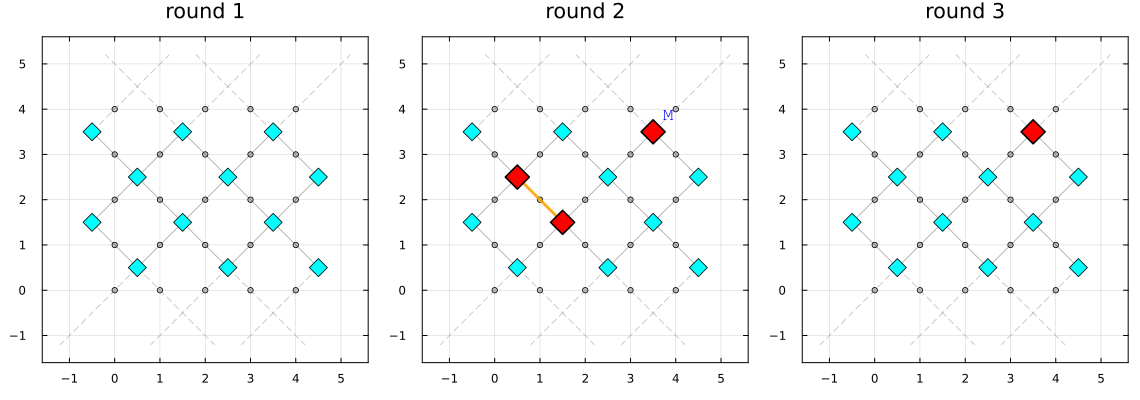

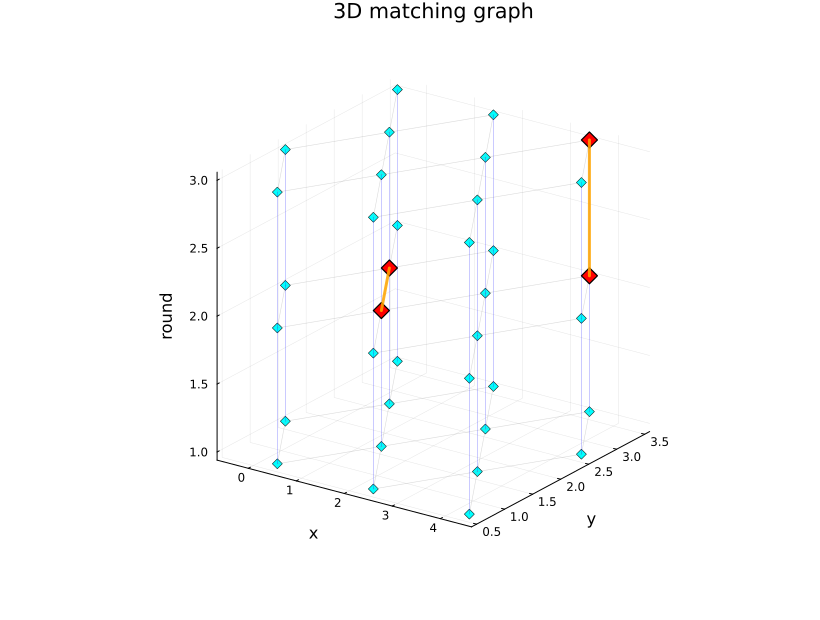

In [17]:
let
    target_stab = 8
    result = run_rounds(R;
        physical_errors = Dict(2 => [(1, 2)]),
        meas_errors     = Dict(2 => [target_stab]))
    decoded = decode(result.detectors, g)
    summarise(result, decoded)
    @assert Set(decoded.frame_update) == Set([(1, 2)])
    @assert Set(decoded.meas_err)     == Set([(target_stab, 2)])

    display(plot_all_rounds(result.detectors, decoded.pairs, g;
                            meas_err = decoded.meas_err))
    display(plot_3d(result.detectors, decoded.pairs, g))
end